In [2]:
import cosmic
from cosmic.output import load_initC
import h5py as h5
import os

import pandas as pd

import legwork as lw
import astropy.units as u
import numpy as np

import sys
sys.path.append("../helpers")

import initial_dists
from truncation import get_f_trunc
from sfh import SB15PhiCut
import gala.potential as gp
import cogsworth
import matplotlib.pyplot as plt
from scipy.integrate import quad

# Load data

In [3]:
FOLDER = "/mnt/ceph/users/twagg/lisa-dcos/fiducial"
dco_type = "BHBH"

In [4]:
all_formation_rows = pd.read_hdf(f"{FOLDER}/{dco_type}_formation_rows.h5", key="formation_rows")

In [5]:
all_kick_infos = pd.read_hdf(f"{FOLDER}/{dco_type}_kick_info.h5", key="kick_info")

# Construct SFHs

In [6]:
Z_BIN_CENTRES = np.logspace(-4, np.log10(0.03), 50).round(5)
BIN_WIDTH = (np.log10(Z_BIN_CENTRES)[1] - np.log10(Z_BIN_CENTRES)[0]) / 2
Z_BIN_EDGES = np.logspace(np.log10(Z_BIN_CENTRES[0]) - BIN_WIDTH, np.log10(Z_BIN_CENTRES[-1]) + BIN_WIDTH, 51)
Z_BIN_EDGES[0] = Z_BIN_CENTRES[0]
Z_BIN_EDGES[-1] = Z_BIN_CENTRES[-1]

In [7]:
regular = cogsworth.sfh.SandersBinney2015(potential=gp.MilkyWayPotential(version='v2'))

# Compute MW weights

In [8]:
if os.path.isfile("MW_Z_weights.npy"):
    MW_weights = np.load("MW_Z_weights.npy")
else:
    g = cogsworth.sfh.SandersBinney2015(potential=gp.MilkyWayPotential2022())
    g.sample(10_000_000)
    counts, _ = np.histogram(g.Z.value, bins=Z_BIN_EDGES)
    MW_weights = counts / np.sum(counts)
    np.save("MW_Z_weights.npy", MW_weights)

all_formation_rows["MW_Z_weight"] = 0.0
for Z in Z_BIN_CENTRES:
    all_formation_rows.loc[all_formation_rows["metallicity"] == Z, "MW_Z_weight"] = MW_weights[np.digitize(Z, Z_BIN_CENTRES) - 1]

In [262]:
rand_sample = all_formation_rows.sample(500_000, weights="MW_Z_weight", replace=True)
rand_kicks = all_kick_infos.loc[rand_sample.index]

In [263]:
target_counts, _ = np.histogram(rand_sample["metallicity"].values, bins=Z_BIN_EDGES)

In [264]:
counts = np.zeros_like(target_counts)
rnd = 0
sfhs = []

sample_size = target_counts.sum() * 8
while np.sum(counts) < np.sum(target_counts):
    print(f"Round {rnd}: About to sample {sample_size} points from SFH")
    print("  Missing counts per bin: ", target_counts - counts)
    regular.sample(int(sample_size))
    regular.Z[regular.Z < 1e-4] = 1e-4
    regular.Z[regular.Z > 0.03] = 0.03

    for i in range(len(target_counts)):
        if counts[i] == target_counts[i]:
            continue

        matches = (Z_BIN_EDGES[i] <= regular.Z.value) & (regular.Z.value < Z_BIN_EDGES[i+1])
        if matches.sum() == 0:
            continue
        elif matches.sum() > target_counts[i] - counts[i]:
            matches[np.random.choice(np.where(matches)[0], matches.sum() - (target_counts[i] - counts[i]), replace=False)] = False

        sfhs.append(regular[matches])
        counts[i] = min(target_counts[i], counts[i] + matches.sum())

    rnd += 1

Round 0: About to sample 4000000 points from SFH
  Missing counts per bin:  [  244   618   671   904   985  1102  1449  1729  2104  2505  3163  3735
  4480  5195  6061  7298  8640 10393 12060 13406 15982 19125 23317 27527
 30861 34892 38522 40791 40562 40905 36517 28999 20661  7419  2700  1762
  1125   609   441   232   151    82    52    21     2     1     0     0
     0     0]


In [329]:
p = cogsworth.pop.Population(
    len(rand_sample), sfh_model=cogsworth.sfh.SandersBinney2015(potential=gp.MilkyWayPotential(version='v2')),
    galactic_potential=gp.MilkyWayPotential(version='v2'),
    ini_file="../src/params.ini", processes=2, store_entire_orbits=False,
    orbit_integration_retry_settings={
        "timestep_multiplier": 0.25,
        "max_retries": 4
    }
)
p._initial_galaxy = cogsworth.sfh.concat(*sfhs)

rand_sample.index = np.arange(len(rand_sample))
rand_sample["bin_num"] = rand_sample.index.values

rand_kicks.index = np.arange(len(rand_kicks)) // 2
rand_kicks["bin_num"] = rand_kicks.index.values
rand_kicks[['disrupted', 'delta_vsysx_2', 'delta_vsysy_2', 'delta_vsysz_2']] = 0.0

p._initial_binaries = rand_sample
p._kick_info = rand_kicks

bpp = rand_sample.copy()
bpp.drop(columns=["MW_Z_weight", "metallicity"], inplace=True)
bpp["evol_type"] = 15

p._bpp = bpp

sources = p.to_legwork_sources(distances=np.full(len(p), 8.0) * u.kpc)
sources.get_merger_time(exact=False)

is_inspiraling = (
    (p.initial_galaxy.tau >= p.bpp["tphys"].values * u.Myr) &                   # has formed a BHBH
    (p.initial_galaxy.tau <= sources.t_merge + p.bpp["tphys"].values * u.Myr)   # but hasn't merged yet
)
p_insp = p[is_inspiraling]

sources_insp = p_insp.to_legwork_sources(distances=np.full(len(p_insp), 10.0) * u.pc)
sources_insp.evolve_sources(t_evol=p_insp.initial_galaxy.tau)
sources_insp.get_snr(verbose=True)
p_insp_loud = p_insp[sources_insp.snr > 7]

p_insp_loud.perform_galactic_evolution()
sources_insp_loud = p_insp_loud.to_legwork_sources(assume_mw_galactocentric=True)
sources_insp_loud.evolve_sources(t_evol=p_insp_loud.initial_galaxy.tau)
sources_insp_loud.get_snr(verbose=True)

weights_detect = np.sum(p_insp_loud.bpp[sources_insp_loud.snr > 7]["weights"])
weights_all = np.sum(p.bpp["weights"])

f_detect = weights_detect / weights_all
print(f_detect, weights_detect, weights_all, (sources_insp_loud.snr > 7).sum())

Calculating SNR for 70128 sources
	140 sources have already merged
	69988 sources are stationary
		15444 sources are stationary and circular
		54544 sources are stationary and eccentric


Integrating orbits: 100%|██████████| 7681/7681 [00:39<00:00, 195.03it/s] 
cogsworth warning: 48 orbit(s) failed numerical integration, removing them. This can occur due to NaNs in stellar evolution or extreme orbits (e.g. passing directly through the galactic centre) that Gala cannot handle. Information for these systems was saved to `./failed_integration_binaries_13.h5`. This includes their initial_binaries, bpp, kick_info, and initial galaxy objects.


Calculating SNR for 7633 sources
	0 sources have already merged
	7633 sources are stationary
		3093 sources are stationary and circular
		4540 sources are stationary and eccentric
2.3273570513923917e-05 0.5365041576359493 23052.07777702068 16


In [333]:
pd.read_hdf("failed_integration_binaries_12.h5", key="initial_binaries") == pd.read_hdf("failed_integration_binaries_13.h5", key="initial_binaries")

,tphys,mass_1,mass_2,kstar_1,kstar_2,sep,ecc,bin_num,metallicity,weights,MW_Z_weight,phase_sn_1,phase_sn_2,inc_sn_1,inc_sn_2
1983,True,True,True,True,True,True,True,True,True,True,True,False,False,False,False
2070,True,True,True,True,True,True,True,True,True,True,True,False,False,False,False
2671,True,True,True,True,True,True,True,True,True,True,True,False,False,False,False
3973,True,True,True,True,True,True,True,True,True,True,True,False,False,False,False
4897,True,True,True,True,True,True,True,True,True,True,True,False,False,False,False
5483,True,True,True,True,True,True,True,True,True,True,True,False,False,False,False
7745,True,True,True,True,True,True,True,True,True,True,True,False,False,False,False
15716,True,True,True,True,True,True,True,True,True,True,True,False,False,False,False
17160,True,True,True,True,True,True,True,True,True,True,True,False,False,False,False
21434,True,True,True,True,True,True,True,True,True,True,True,False,False,False,False


In [323]:
p = cogsworth.pop.Population(
    len(rand_sample), sfh_model=cogsworth.sfh.SandersBinney2015(potential=gp.MilkyWayPotential(version='v2')),
    galactic_potential=gp.MilkyWayPotential(version='v2'),
    ini_file="../src/params.ini", processes=2, store_entire_orbits=False,
    orbit_integration_retry_settings={
        "timestep_multiplier": 0.25,
        "max_retries": 4
    }
)
p._initial_galaxy = cogsworth.sfh.concat(*sfhs)

rand_sample.index = np.arange(len(rand_sample))
rand_sample["bin_num"] = rand_sample.index.values

rand_kicks.index = np.arange(len(rand_kicks)) // 2
rand_kicks["bin_num"] = rand_kicks.index.values
rand_kicks[['disrupted', 'delta_vsysx_2', 'delta_vsysy_2', 'delta_vsysz_2']] = 0.0

p._initial_binaries = rand_sample
p._kick_info = rand_kicks

bpp = rand_sample.copy()
bpp.drop(columns=["MW_Z_weight", "metallicity"], inplace=True)
bpp["evol_type"] = 15

p._bpp = bpp

sources = p.to_legwork_sources(distances=np.full(len(p), 8.0) * u.kpc)
sources.get_merger_time(exact=False)

is_inspiraling = (
    (p.initial_galaxy.tau >= p.bpp["tphys"].values * u.Myr) &                   # has formed a BHBH
    (p.initial_galaxy.tau <= sources.t_merge + p.bpp["tphys"].values * u.Myr)   # but hasn't merged yet
)
p_insp = p[is_inspiraling]

sources_insp = p_insp.to_legwork_sources(distances=np.full(len(p_insp), 10.0) * u.pc)
sources_insp.evolve_sources(t_evol=p_insp.initial_galaxy.tau)
sources_insp.get_snr(verbose=True)
p_insp_loud = p_insp[sources_insp.snr > 7]

p_insp_loud.perform_galactic_evolution()
sources_insp_loud = p_insp_loud.to_legwork_sources(assume_mw_galactocentric=True)
sources_insp_loud.evolve_sources(t_evol=p_insp_loud.initial_galaxy.tau)
sources_insp_loud.get_snr(verbose=True)

weights_detect = np.sum(p_insp_loud.bpp[sources_insp_loud.snr > 7]["weights"])
weights_all = np.sum(p.bpp["weights"])

f_detect = weights_detect / weights_all
print(f_detect, weights_detect, weights_all, (sources_insp_loud.snr > 7).sum())

Calculating SNR for 70128 sources
	140 sources have already merged
	69988 sources are stationary
		15444 sources are stationary and circular
		54544 sources are stationary and eccentric


Integrating orbits: 100%|██████████| 7681/7681 [00:39<00:00, 196.88it/s] 
cogsworth warning: 48 orbit(s) failed numerical integration, removing them. This can occur due to NaNs in stellar evolution or extreme orbits (e.g. passing directly through the galactic centre) that Gala cannot handle. Information for these systems was saved to `./failed_integration_binaries_12.h5`. This includes their initial_binaries, bpp, kick_info, and initial galaxy objects.


Calculating SNR for 7633 sources
	0 sources have already merged
	7633 sources are stationary
		3093 sources are stationary and circular
		4540 sources are stationary and eccentric
1.7893330639948857e-05 0.41247844960204827 23052.07777702068 11


In [334]:
total = 0

n_formed = 2e6
avg_m_form = quad(lambda m: initial_dists.IMF(m) * m, 19, 150)[0] / quad(lambda m: initial_dists.IMF(m), 19, 150)[0] * 1.5
f_trunc = get_f_trunc(m1_low=19, m1_upp=150, m1_uni_low=0.08, m1_uni_upp=150, m2_low=0.08)

for Z in Z_BIN_CENTRES:
    formation_rows_Z = all_formation_rows[all_formation_rows["metallicity"] == Z]
    p_Z = MW_weights[np.digitize(Z, Z_BIN_CENTRES) - 1]
    weights_sum = np.sum(formation_rows_Z["weights"].values)
    total += weights_sum * p_Z / (avg_m_form / f_trunc * n_formed)

print(total * 1e11 * f_detect)

10.328752208657354


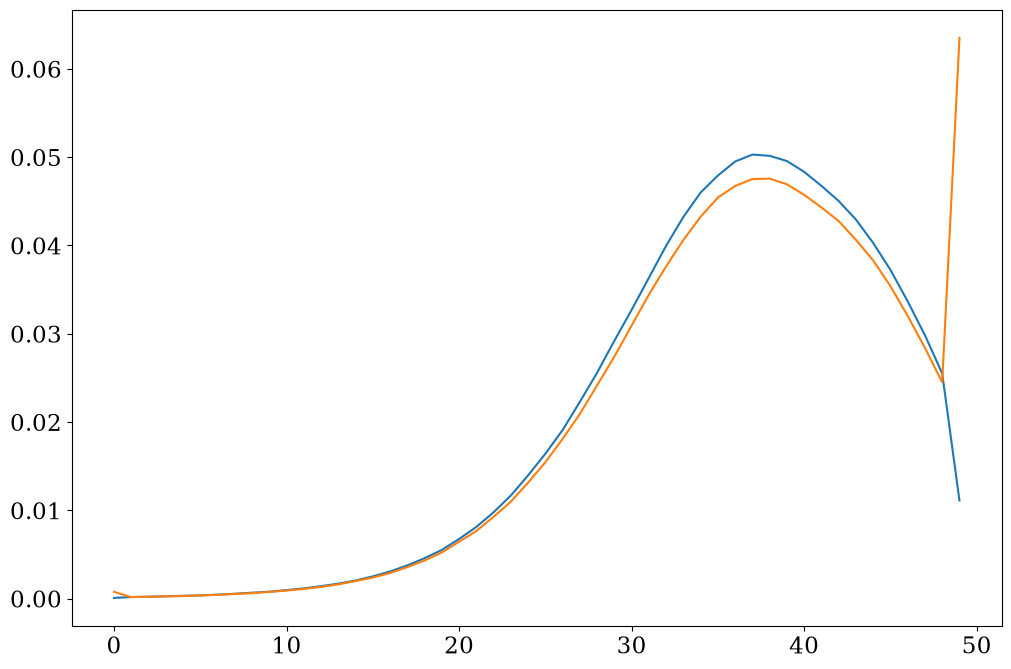

In [344]:
plt.plot(MW_weights)
plt.plot(MW_weights_clipped)

In [22]:
star_forming_mass_at_Z = []
n_target_at_Z = []
for Z in Z_BIN_CENTRES:
    with h5.File(f"{FOLDER}/BHBH_Z_{Z}.h5", "r") as f:
        mass_1, q = f["stroopwafel"]["samples"][...][:, 0], f["stroopwafel"]["samples"][...][:, 1]
        mass_2 = mass_1 * q
        weights = f["stroopwafel"]["weights"][...]
        star_forming_mass_at_Z.append(np.sum((mass_1 + mass_2) * weights))
    
    formation_rows_Z = all_formation_rows[all_formation_rows["metallicity"] == Z]
    n_target_at_Z.append(np.sum(formation_rows_Z["weights"].values))

star_forming_mass_at_Z = np.array(star_forming_mass_at_Z)
n_target_at_Z = np.array(n_target_at_Z)

In [26]:
f_trunc = get_f_trunc(m1_low=19, m1_upp=150, m1_uni_low=0.08, m1_uni_upp=150, m2_low=0.08)
np.sum(n_target_at_Z * MW_weights / (star_forming_mass_at_Z / f_trunc)) * 10.4e10

np.float64(467907.85842174385)

In [16]:
get_f_trunc(m1_low=19, m1_upp=150, m1_uni_low=0.08, m1_uni_upp=150, m2_low=0.08) / get_f_trunc(m1_low=19, m1_upp=150, m1_uni_low=0.08, m1_uni_upp=150, m2_low=0.08, f_bin=0.5)

1.8700116909991107

In [271]:
g = cogsworth.sfh.SandersBinney2015(potential=gp.MilkyWayPotential(version='v2'))
g.sample(10_000_000)
sampled_Z = g.Z.value
sampled_Z[sampled_Z > np.max(Z_BIN_EDGES)] = np.max(Z_BIN_EDGES)
sampled_Z[sampled_Z < np.min(Z_BIN_EDGES)] = np.min(Z_BIN_EDGES)
counts, _ = np.histogram(sampled_Z, bins=Z_BIN_EDGES)
MW_weights_clipped = counts / np.sum(counts)

In [286]:
f_trunc / get_f_trunc(m1_low=19, m1_upp=150, m2_low=0.08, f_bin=0.5)

1.8700116909991107

In [290]:
15*1.58*1.87

44.31900000000001

In [289]:
get_f_trunc(m1_low=19, m1_upp=150, m2_low=0.08, f_bin=0.5) / get_f_trunc(m1_low=5, m1_upp=150, m2_low=0.08, f_bin=0.5)

0.4858059798598817

In [9]:
total = 0

n_formed = 2e6
avg_m_form = quad(lambda m: initial_dists.IMF(m) * m, 19, 150)[0] / quad(lambda m: initial_dists.IMF(m), 19, 150)[0] * 1.5
f_trunc = get_f_trunc(m1_low=19, m1_upp=150, m1_uni_low=0.08, m1_uni_upp=150, m2_low=0.08)

for Z in Z_BIN_CENTRES:
    formation_rows_Z = all_formation_rows[all_formation_rows["metallicity"] == Z]
    p_Z = MW_weights[np.digitize(Z, Z_BIN_CENTRES) - 1]
    weights_sum = np.sum(formation_rows_Z["weights"].values)

    with h5.File(f"{FOLDER}/BHBH_Z_{Z}.h5", "r") as f:
        mass_1, q = f["stroopwafel"]["samples"][...][:, 0], f["stroopwafel"]["samples"][...][:, 1]
        mass_2 = mass_1 * q
        weights = f["stroopwafel"]["weights"][...]
        mass_at_Z = np.sum((mass_1 + mass_2) * weights)

    total += weights_sum * p_Z / (mass_at_Z / f_trunc)

print(total * 1e11 * f_detect)

KeyboardInterrupt: 

In [253]:
total_mass / (40 * 1.5 * 2e6)

np.float64(50.20484736804675)

In [ ]:
DCO_TYPES = ["NSWD", "NSNS", "BHWD", "BHNS", "BHBH"]
kstar_masks = [([13], [10, 11, 12]), ([13], [13]), ([14], [10, 11, 12]), ([14], [13]), ([14], [14])]
FOLDER = "/mnt/ceph/users/twagg/lisa-dcos/fiducial"

for kstars, dco_type in zip(kstar_masks, DCO_TYPES):
    if dco_type != "BHBH":
        continue
    print(f"Processing {dco_type}...")
    total_mass = 0.0
    for file in os.listdir(FOLDER):
        if file.startswith(f"{dco_type}_Z_"):
            with h5.File(f"{FOLDER}/{file}", "r") as f:
                mass_1, q = f["stroopwafel"]["samples"][...][:, 0], f["stroopwafel"]["samples"][...][:, 1]
                mass_2 = mass_1 * q
                weights = f["stroopwafel"]["weights"][...]
                mass_at_Z = np.sum((mass_1 + mass_2) * weights)
                print(f"  {file}: {mass_at_Z:.2f} Msun")
                total_mass += mass_at_Z

Processing BHBH...
  BHBH_Z_0.00415.h5: 120312674.37 Msun
  BHBH_Z_0.00115.h5: 121177304.66 Msun
  BHBH_Z_0.01182.h5: 119233369.19 Msun
  BHBH_Z_0.00129.h5: 121133300.48 Msun
  BHBH_Z_0.01492.h5: 119004234.98 Msun
  BHBH_Z_0.02377.h5: 118600100.59 Msun
  BHBH_Z_0.0026.h5: 120508105.42 Msun
  BHBH_Z_0.0002.h5: 121529216.36 Msun
  BHBH_Z_0.02116.h5: 118600994.52 Msun
  BHBH_Z_0.00011.h5: 121419554.46 Msun
  BHBH_Z_0.00145.h5: 121043141.50 Msun
  BHBH_Z_0.00025.h5: 121165246.98 Msun
  BHBH_Z_0.0267.h5: 118517921.22 Msun
  BHBH_Z_0.00016.h5: 121542533.69 Msun
  BHBH_Z_0.0001.h5: 121476598.15 Msun
  BHBH_Z_0.00369.h5: 120527276.93 Msun
  BHBH_Z_0.00029.h5: 121515588.85 Msun
  BHBH_Z_0.00091.h5: 121397657.49 Msun
  BHBH_Z_0.03.h5: 118425915.82 Msun
  BHBH_Z_0.00834.h5: 119571627.56 Msun
  BHBH_Z_0.00032.h5: 121499198.93 Msun
  BHBH_Z_0.0004.h5: 121154170.75 Msun
  BHBH_Z_0.00013.h5: 121413559.15 Msun
  BHBH_Z_0.00292.h5: 120457646.30 Msun
  BHBH_Z_0.01328.h5: 119175654.16 Msun
  BHBH_Z_0.000

---
# OLD

In [135]:
low_counts = target_counts.copy()
low_counts[30:] = 0
high_counts = target_counts.copy()
high_counts[:30] = 0

low_galaxy_counts = np.zeros_like(counts)
high_galaxy_counts = np.zeros_like(counts)
rnd = 0

sfhs = []

for count_tracker, count_target, sfh_model, sample_size in zip(
    [low_galaxy_counts, high_galaxy_counts],
    [low_counts, high_counts],
    [low_Z, regular],
    [2 * low_counts.sum(), 1.2 * high_counts.sum()]
):
    while np.sum(count_tracker) < np.sum(count_target):
        print(f"Round {rnd}: Current {count_tracker}: {np.sum(count_tracker)} / {np.sum(count_target)}")
        print("  Missing counts per bin: ", count_target - count_tracker)
        sfh_model.sample(int(sample_size))
        sfh_model.Z[sfh_model.Z < 1e-4] = 1e-4
        sfh_model.Z[sfh_model.Z > 0.03] = 0.03

        for i in range(len(count_target)):
            if count_tracker[i] == count_target[i]:
                continue

            matches = (Z_BIN_EDGES[i] <= sfh_model.Z.value) & (sfh_model.Z.value < Z_BIN_EDGES[i+1])
            if matches.sum() == 0:
                continue
            elif matches.sum() > count_target[i] - count_tracker[i]:
                matches[np.random.choice(np.where(matches)[0], matches.sum() - (count_target[i] - count_tracker[i]), replace=False)] = False

            sfhs.append(sfh_model[matches])
            count_tracker[i] = min(count_target[i], count_tracker[i] + matches.sum())

        rnd += 1

Round 0: Current [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0]: 0 / 161423
  Missing counts per bin:  [   40   103   131   185   259   348   421   613   765   854  1121  1341
  1669  2180  2456  3068  3678  4500  5158  6293  7263  8721  9995 11507
 12904 14060 15418 15664 15802 14906     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0]


KeyboardInterrupt: Error in sample(): Keyboard interrupt